In [1]:
# 1. Installation de PySpark
!pip install pyspark -q

# 2. Création de la Session PySpark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("F1_Predictor_ValueBets") \
    .config("spark.sql.repl.eagerEval.enabled", True) \
    .getOrCreate()

print("Moteur PySpark démarré en local ! 🏎️")

Moteur PySpark démarré en local ! 🏎️


In [3]:
# À chaque nouvelle connexion:
# Décommenter et exécuter après avoir glissé le  fichier "f1_data.zip" issu du Drive dans Colab
!unzip -q f1_data.zip

df_results = spark.read.csv("results.csv", header=True, inferSchema=True)
df_races = spark.read.csv("races.csv", header=True, inferSchema=True)
df_drivers = spark.read.csv("drivers.csv", header=True, inferSchema=True)

df_results.show(5)

replace circuits.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
+--------+------+--------+-------------+------+----+--------+------------+-------------+------+----+-----------+------------+----------+----+--------------+---------------+--------+
|resultId|raceId|driverId|constructorId|number|grid|position|positionText|positionOrder|points|laps|       time|milliseconds|fastestLap|rank|fastestLapTime|fastestLapSpeed|statusId|
+--------+------+--------+-------------+------+----+--------+------------+-------------+------+----+-----------+------------+----------+----+--------------+---------------+--------+
|       1|    18|       1|            1|    22|   1|       1|           1|            1|  10.0|  58|1:34:50.616|     5690616|        39|   2|      1:27.452|        218.300|       1|
|       2|    18|       2|            2|     3|   5|       2|           2|            2|   8.0|  58|     +5.478|     5696094|        41|   3|      1:27.739|        217.586|       1|
|       3|    18|       3|  

In [4]:
# On convertit les DataFrames Spark en pandas
# .toPandas() rapatrie les données du moteur Spark vers la mémoire Python classique
# C'est l'étape "passerelle" entre PySpark et scikit-learn

df_results_pd = df_results.toPandas()
df_races_pd = df_races.toPandas()
df_drivers_pd = df_drivers.toPandas()

print("✅ Conversion OK")
print(f"Results : {df_results_pd.shape[0]} lignes, {df_results_pd.shape[1]} colonnes")
print(df_results_pd.head(3))

✅ Conversion OK
Results : 26759 lignes, 18 colonnes
   resultId  raceId  driverId  constructorId number  grid position  \
0         1      18         1              1     22     1        1   
1         2      18         2              2      3     5        2   
2         3      18         3              3      7     7        3   

  positionText  positionOrder  points  laps         time milliseconds  \
0            1              1    10.0    58  1:34:50.616      5690616   
1            2              2     8.0    58       +5.478      5696094   
2            3              3     6.0    58       +8.163      5698779   

  fastestLap rank fastestLapTime fastestLapSpeed  statusId  
0         39    2       1:27.452         218.300         1  
1         41    3       1:27.739         217.586         1  
2         41    5       1:28.090         216.719         1  


In [5]:
import pandas as pd
import numpy as np

# Les CSV Kaggle utilisent "\N" pour dire "valeur manquante"
# On les remplace par NaN (la valeur manquante standard de pandas)
df_results_pd = df_results_pd.replace("\\N", np.nan)

# On garde uniquement les colonnes utiles pour la prédiction
df = df_results_pd[["raceId", "driverId", "constructorId", "grid", "positionOrder"]].copy()

# On supprime les lignes où grid = 0
# (grid = 0 signifie que le pilote n'a pas pris le départ — pas utile pour prédire)
df = df[df["grid"] != "0"]

# On convertit les colonnes en nombres
# (elles sont en "object" = texte après le replace, il faut les remettre en int/float)
for col in ["grid", "positionOrder", "driverId", "constructorId"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# On ajoute l'année et le circuit depuis races
# (une jointure = on relie deux tables sur une colonne commune, ici raceId)
df = df.merge(
    df_races_pd[["raceId", "year", "circuitId"]],
    on="raceId",
    how="left"
)

# On supprime les lignes qui ont encore des valeurs manquantes
df = df.dropna()

print(f"✅ Shape après nettoyage : {df.shape}")
print(f"Années couvertes : {int(df['year'].min())} → {int(df['year'].max())}")
print(df.head(3))

✅ Shape après nettoyage : (26759, 7)
Années couvertes : 1950 → 2024
   raceId  driverId  constructorId  grid  positionOrder  year  circuitId
0      18         1              1     1              1  2008          1
1      18         2              2     5              2  2008          1
2      18         3              3     7              3  2008          1


In [6]:
# On charge qualifying depuis Spark puis on convertit en pandas
df_qualifying = spark.read.csv("qualifying.csv", header=True, inferSchema=True).toPandas()
df_circuits = spark.read.csv("circuits.csv", header=True, inferSchema=True).toPandas()

# Nettoyage
df_qualifying = df_qualifying.replace("\\N", np.nan)
df_circuits = df_circuits.replace("\\N", np.nan)

# On récupère la position en qualif (Q1/Q2/Q3 → position finale)
df_qual = df_qualifying[["raceId", "driverId", "position"]].copy()
df_qual["position"] = pd.to_numeric(df_qual["position"], errors="coerce")
df_qual = df_qual.rename(columns={"position": "quali_position"})

# On jointue les coordonnées GPS sur les courses
df_races_geo = df_races_pd.merge(
    df_circuits[["circuitId", "lat", "lng"]],
    on="circuitId",
    how="left"
)
df_races_geo["lat"] = pd.to_numeric(df_races_geo["lat"], errors="coerce")
df_races_geo["lng"] = pd.to_numeric(df_races_geo["lng"], errors="coerce")

print(f"✅ Qualifying : {df_qual.shape[0]} lignes")
print(f"✅ Circuits avec GPS : {df_races_geo[['raceId','lat','lng']].dropna().shape[0]} courses géolocalisées")
print(df_races_geo[["raceId", "name", "date", "lat", "lng"]].head(3))

✅ Qualifying : 10494 lignes
✅ Circuits avec GPS : 1125 courses géolocalisées
   raceId                   name        date       lat      lng
0       1  Australian Grand Prix  2009-03-29 -37.84970  144.968
1       2   Malaysian Grand Prix  2009-04-05   2.76083  101.738
2       3     Chinese Grand Prix  2009-04-19  31.33890  121.220


In [7]:
import requests
import time
import os
from tqdm import tqdm

def get_weather(lat, lng, date):
    """
    Appelle l'API Open-Meteo pour récupérer la météo historique
    à une date et coordonnées GPS données.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lng,
        "start_date": date,
        "end_date": date,
        "daily": "temperature_2m_mean,precipitation_sum,windspeed_10m_max",
        "timezone": "auto"
    }
    try:
        res = requests.get(url, params=params, timeout=10)
        data = res.json()
        daily = data.get("daily", {})
        return {
            "temp_mean": daily.get("temperature_2m_mean", [None])[0],
            "precipitation": daily.get("precipitation_sum", [None])[0],
            "wind_speed": daily.get("windspeed_10m_max", [None])[0],
        }
    except Exception:
        return {"temp_mean": None, "precipitation": None, "wind_speed": None}

# Si le fichier existe déjà, on le charge directement (évite de refaire les appels)
if os.path.exists("weather_data.csv"):
    df_weather = pd.read_csv("weather_data.csv")
    print(f"✅ Météo chargée depuis le cache : {df_weather.shape[0]} lignes")

else:
    # Courses uniques avec GPS et date
    courses = df_races_geo[["raceId", "date", "lat", "lng"]].dropna().drop_duplicates("raceId")

    # Appels API avec barre de progression
    weather_rows = []
    for _, row in tqdm(courses.iterrows(), total=len(courses), desc="Récupération météo"):
        meteo = get_weather(row["lat"], row["lng"], row["date"])
        meteo["raceId"] = row["raceId"]
        weather_rows.append(meteo)
        time.sleep(0.1)

    df_weather = pd.DataFrame(weather_rows)
    print(f"\n✅ Météo récupérée pour {df_weather.dropna().shape[0]} courses")
    print(df_weather.head(5))

    # Sauvegarde CSV immédiate
    df_weather.to_csv("weather_data.csv", index=False)
    print("💾 Sauvegardé dans weather_data.csv !")

    # Téléchargement automatique
    from google.colab import files
    files.download("weather_data.csv")

Récupération météo: 100%|██████████| 1125/1125 [11:58<00:00,  1.56it/s]


✅ Météo récupérée pour 1124 courses
   temp_mean  precipitation  wind_speed  raceId
0       17.0            0.0        16.6       1
1       25.4           20.3         9.3       2
2       18.4           24.0        32.3       3
3       28.5            0.0        32.7       4
4       17.8            0.3        14.6       5
💾 Sauvegardé dans weather_data.csv !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# On assemble toutes nos sources en un seul DataFrame
# C'est la table finale qui servira à entraîner le modèle

# 1. Ajout du qualifying
df = df.merge(df_qual, on=["raceId", "driverId"], how="left")
df["quali_position"] = df["quali_position"].fillna(df["grid"])

# 2. Ajout de la météo
df = df.merge(df_weather, on="raceId", how="left")

# 3. Nettoyage final
df = df.dropna()

print(f"✅ Dataset final : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Colonnes : {list(df.columns)}")
print(df.head(3))

✅ Dataset final : 26726 lignes, 11 colonnes
Colonnes : ['raceId', 'driverId', 'constructorId', 'grid', 'positionOrder', 'year', 'circuitId', 'quali_position', 'temp_mean', 'precipitation', 'wind_speed']
   raceId  driverId  constructorId  grid  positionOrder  year  circuitId  \
0      18         1              1     1              1  2008          1   
1      18         2              2     5              2  2008          1   
2      18         3              3     7              3  2008          1   

   quali_position  temp_mean  precipitation  wind_speed  
0             1.0       28.3            0.0        23.1  
1             5.0       28.3            0.0        23.1  
2             7.0       28.3            0.0        23.1  


In [9]:
from sklearn.model_selection import train_test_split

FEATURES = ["grid", "driverId", "constructorId", "circuitId", "year",
            "quali_position", "temp_mean", "precipitation", "wind_speed"]
TARGET = "positionOrder"

X = df[FEATURES]
y = df[TARGET]

# 1. On sépare d'abord 70% train / 30% reste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# 2. On coupe le reste en 50/50 → 15% validation / 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"✅ Train      : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"✅ Validation : {X_val.shape[0]} lignes ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"✅ Test       : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.0f}%)")

✅ Train      : 18708 lignes (70%)
✅ Validation : 4009 lignes (15%)
✅ Test       : 4009 lignes (15%)


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# On utilise un Regressor (et non Classifier) car on prédit un nombre (position)
# n_estimators = nombre d'arbres de décision dans la forêt
# random_state = graine aléatoire pour reproduire les mêmes résultats
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("✅ Modèle entraîné !")

# Évaluation sur la validation
y_pred_val = model.predict(X_val)
mae_val = mean_absolute_error(y_val, y_pred_val)
print(f"MAE Validation : {mae_val:.2f} positions d'erreur en moyenne")

# Évaluation finale sur le test (jamais vu par le modèle)
y_pred_test = model.predict(X_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
print(f"MAE Test       : {mae_test:.2f} positions d'erreur en moyenne")

✅ Modèle entraîné !
MAE Validation : 4.85 positions d'erreur en moyenne
MAE Test       : 4.82 positions d'erreur en moyenne


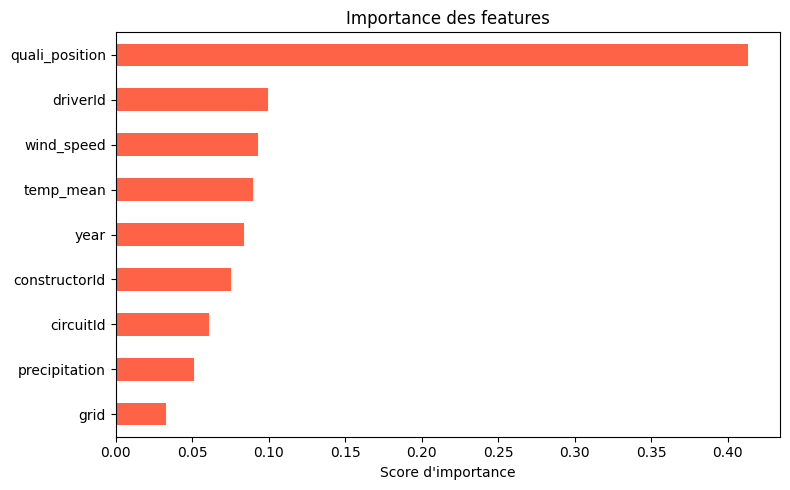

quali_position    0.413617
driverId          0.099805
wind_speed        0.092720
temp_mean         0.089907
year              0.083742
constructorId     0.075366
circuitId         0.061192
precipitation     0.050867
grid              0.032785
dtype: float64


In [11]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="tomato")
plt.title("Importance des features")
plt.xlabel("Score d'importance")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

In [12]:
import joblib
from google.colab import files

# Sauvegarde le modèle entraîné
joblib.dump(model, "model.pkl")
print("✅ model.pkl exporté !")

# Sauvegarde aussi la liste des features dans l'ordre exact
# IMPORTANT : le backend doit envoyer les features dans le même ordre
import json
with open("model_features.json", "w") as f:
    json.dump(FEATURES, f)
print("✅ model_features.json exporté !")

# Téléchargement
files.download("model.pkl")
files.download("model_features.json")

✅ model.pkl exporté !
✅ model_features.json exporté !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
!pip install xgboost -q
print("✅ XGBoost installé !")

✅ XGBoost installé !


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd

# --- Définition des 3 modèles ---
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":           XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
}

# --- Entraînement et évaluation ---
results = []

for name, m in models.items():
    # Entraînement sur le train
    m.fit(X_train, y_train)

    # Évaluation sur validation et test
    mae_val  = mean_absolute_error(y_val,  m.predict(X_val))
    mae_test = mean_absolute_error(y_test, m.predict(X_test))

    results.append({
        "Modèle":         name,
        "MAE Validation": round(mae_val, 3),
        "MAE Test":       round(mae_test, 3),
    })
    print(f"✅ {name} — Val: {mae_val:.3f} | Test: {mae_test:.3f}")

# --- Tableau comparatif ---
df_results_models = pd.DataFrame(results)
df_results_models["Meilleur"] = df_results_models["MAE Test"] == df_results_models["MAE Test"].min()
df_results_models["Meilleur"] = df_results_models["Meilleur"].map({True: "🏆", False: ""})

print("\n📊 Tableau comparatif :")
print(df_results_models.to_string(index=False))

✅ Linear Regression — Val: 6.128 | Test: 6.196
✅ Random Forest — Val: 4.854 | Test: 4.817
✅ XGBoost — Val: 4.829 | Test: 4.797

📊 Tableau comparatif :
           Modèle  MAE Validation  MAE Test Meilleur
Linear Regression           6.128     6.196         
    Random Forest           4.854     4.817         
          XGBoost           4.829     4.797        🏆


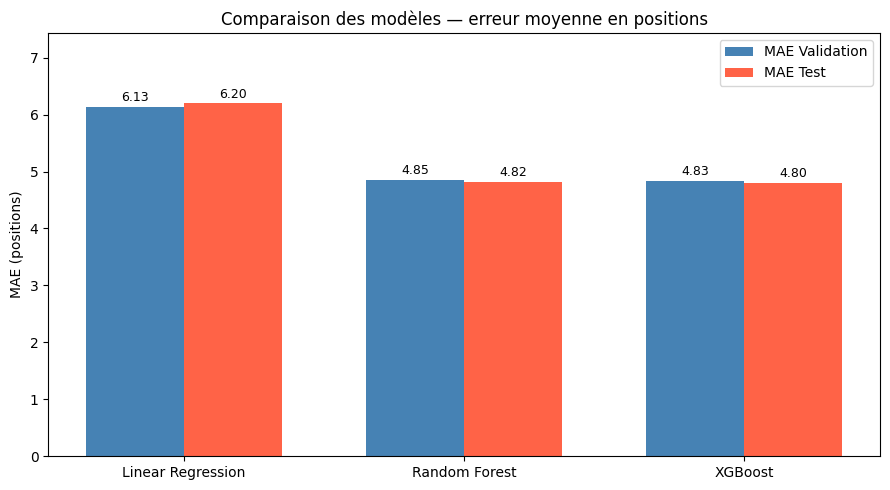

In [15]:
import matplotlib.pyplot as plt
import numpy as np

modeles = df_results_models["Modèle"]
mae_val  = df_results_models["MAE Validation"]
mae_test = df_results_models["MAE Test"]

x = np.arange(len(modeles))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, mae_val,  width, label="MAE Validation", color="steelblue")
bars2 = ax.bar(x + width/2, mae_test, width, label="MAE Test",       color="tomato")

ax.set_ylabel("MAE (positions)")
ax.set_title("Comparaison des modèles — erreur moyenne en positions")
ax.set_xticks(x)
ax.set_xticklabels(modeles)
ax.legend()
ax.set_ylim(0, max(mae_val.max(), mae_test.max()) * 1.2)

# Affiche les valeurs sur les barres
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
# On récupère le meilleur modèle (MAE Test le plus bas)
best_name = df_results_models.loc[df_results_models["MAE Test"].idxmin(), "Modèle"]
best_model = models[best_name]

print(f"🏆 Meilleur modèle : {best_name}")

joblib.dump(best_model, "model.pkl")
print("✅ model.pkl mis à jour avec le meilleur modèle !")

files.download("model.pkl")

🏆 Meilleur modèle : XGBoost
✅ model.pkl mis à jour avec le meilleur modèle !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>